In [1]:
pip install pmdarima


Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install yfinance pandas matplotlib statsmodels


Note: you may need to restart the kernel to use updated packages.


# 1. Timeseries prediction from the real-time fetched data from Kubeflow pipeline

10:57:07 - cmdstanpy - INFO - Chain [1] start processing


 Loading real-time Bitcoin data...
 Training Prophet model...


10:57:08 - cmdstanpy - INFO - Chain [1] done processing


 Plotting forecast...


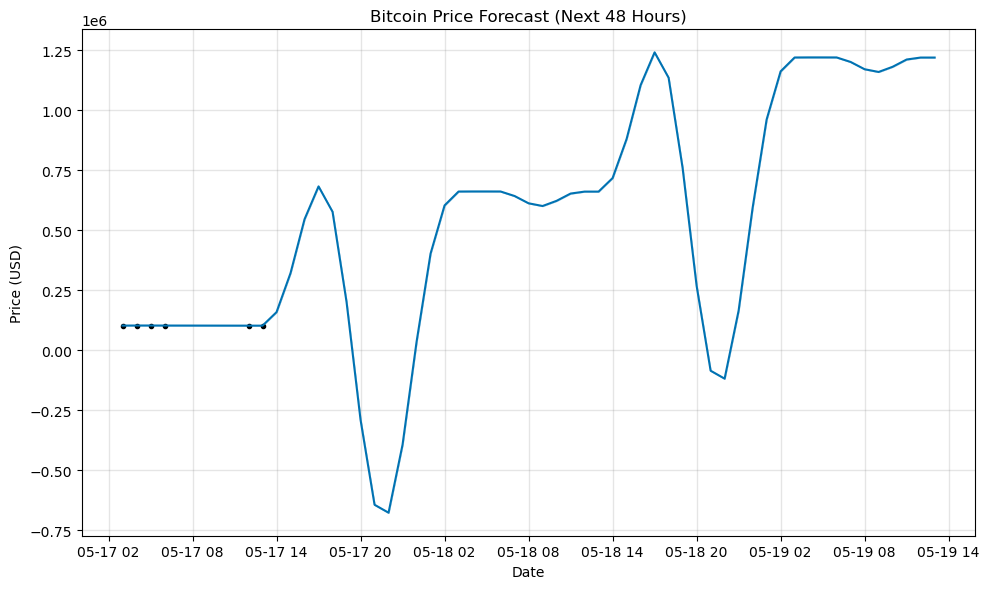

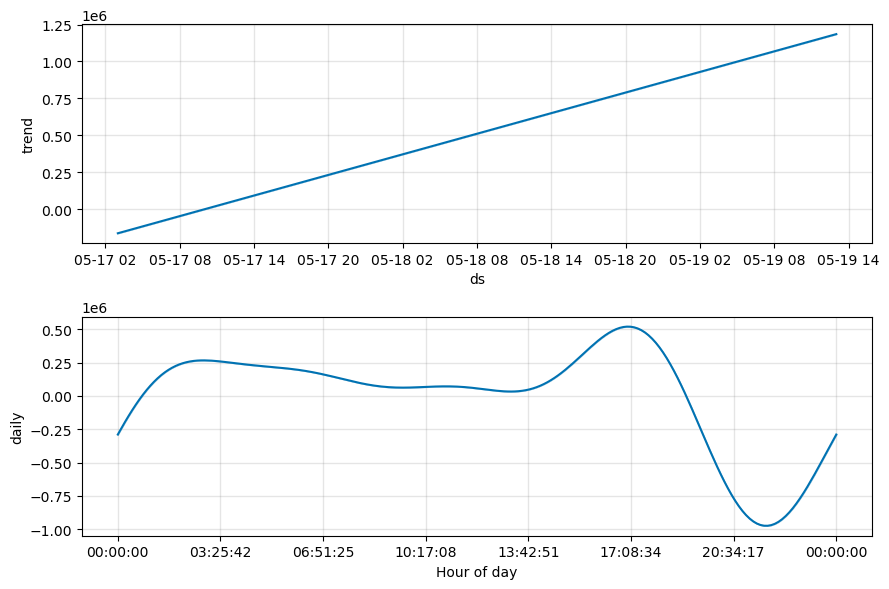

In [ ]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# Step 1: Load the uploaded CSV file 
print(" Loading real-time Bitcoin data...")
df = pd.read_csv('bitcoin_price_log_from_db.csv') #  This is the csv we got after unning the csv_coverter.py script.Make sure this CSV is in the same folder as this script

# Step 2: Preprocess and rename columns for Prophet
df['timestamp'] = pd.to_datetime(df['timestamp'])  # Make sure column is named 'timestamp'
df = df.rename(columns={'timestamp': 'ds', 'price': 'y'})

# Step 3: Resample to hourly average (optional, recommended if minutely data)
df = df.set_index('ds').resample('H').mean().dropna().reset_index()

# Step 4: Fit the Prophet model
print(" Training Prophet model...")
model = Prophet(daily_seasonality=True)
model.fit(df)

# Step 5: Forecast the next 48 hours
future = model.make_future_dataframe(periods=48, freq='H')
forecast = model.predict(future)

# Step 6: Plot forecast
print(" Plotting forecast...")
fig1 = model.plot(forecast)
plt.title("Bitcoin Price Forecast (Next 48 Hours)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 7: Plot components (trend, seasonality)
fig2 = model.plot_components(forecast)
plt.tight_layout()
plt.show()


# 2. Timeseries prediction from the historical data

[*********************100%***********************]  1 of 1 completed

 Training Prophet model...



13:52:26 - cmdstanpy - INFO - Chain [1] start processing
13:52:29 - cmdstanpy - INFO - Chain [1] done processing


 Plotting forecast...


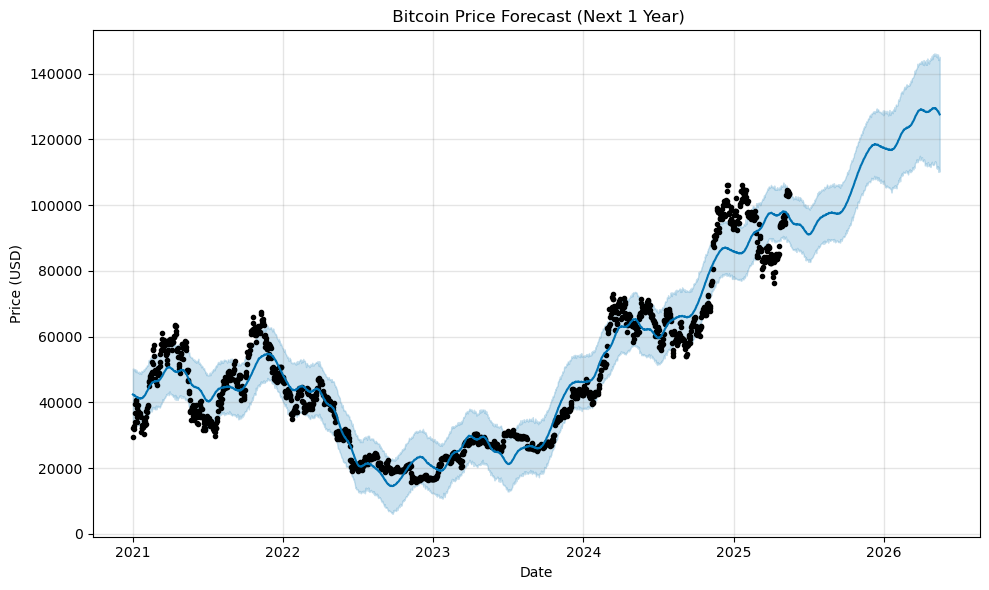

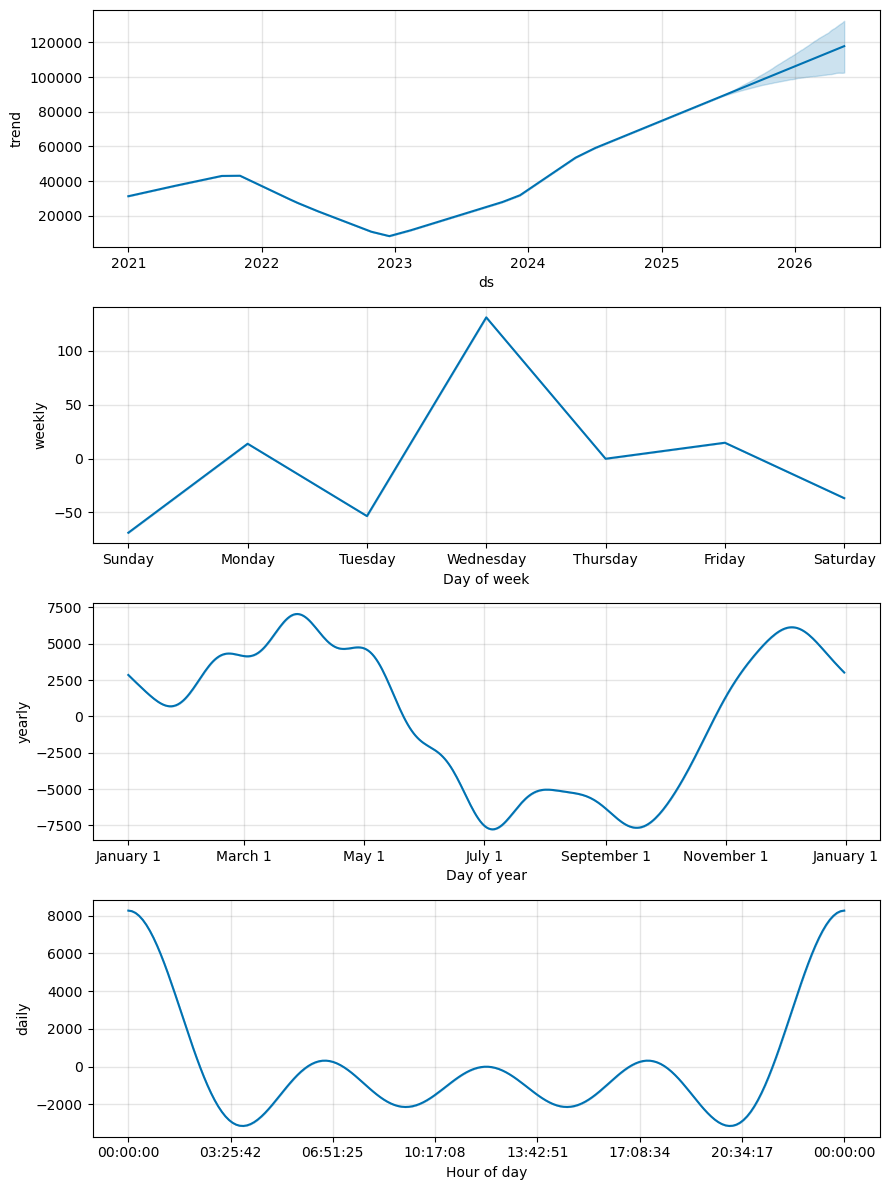

In [7]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from datetime import datetime

# Step 1: Fetch BTC-USD historical data
print(" Downloading historical BTC-USD data...")
btc = yf.download("BTC-USD", start="2021-01-01", end=datetime.today().strftime("%Y-%m-%d"))
btc = btc[['Close']].dropna().reset_index()
btc.columns = ['ds', 'y']  # Prophet expects 'ds' (date) and 'y' (value)

# Step 2: Initialize and train the Prophet model
print(" Training Prophet model...")
model = Prophet(daily_seasonality=True)
model.fit(btc)

# Step 3: Create future dates and forecast
future = model.make_future_dataframe(periods=365)  # 1 year into future
forecast = model.predict(future)

# Step 4: Plot the results
print(" Plotting forecast...")
fig = model.plot(forecast)
plt.title(" Bitcoin Price Forecast (Next 1 Year)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Optional: plot components (trend, seasonality)
model.plot_components(forecast)
plt.tight_layout()
plt.show()
